In [179]:
#import all libraries, pandas for analysis, seaborn and matplitlibe for our visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [180]:
#import data to we can clean and explore

df = pd.read_csv('/Users/chukwuemekaokonkwo/Applications/IDS/adidas-sales/Adidas Sales Dataset.csv')

df = df.drop(columns=['Unnamed: 0'])

df.dtypes

Retailer              str
Retailer ID         int64
Invoice Date          str
Region                str
State                 str
City                  str
Product               str
Price per Unit        str
Units Sold            str
Total Sales           str
Operating Profit      str
Operating Margin      str
Sales Method          str
dtype: object

In [181]:
#see if there are any missing values
df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

In [182]:
#convert numeric columns to integers and not strings

columns_to_convert = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

for cols in columns_to_convert:
    df[cols] = df[cols].str.replace('$', '').str.replace(',', '').str.replace('%', '').astype(float)


In [183]:
#check that the date and units sold have the right datatypes

df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['Units Sold'] = df['Units Sold'].astype(int)

df.dtypes

Retailer                       str
Retailer ID                  int64
Invoice Date        datetime64[us]
Region                         str
State                          str
City                           str
Product                        str
Price per Unit             float64
Units Sold                   int64
Total Sales                float64
Operating Profit           float64
Operating Margin           float64
Sales Method                   str
dtype: object

In [184]:
df = df.rename(columns={ #rename columns to read more clearly
    'Total Sales': 'Total Sales ($)',
    'Operating Profit': 'Operating Profit ($)',
    'Operating Margin': 'Operating Margin (%)',
    'Price per Unit': 'Price per Unit ($)'
})

df

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit ($),Units Sold,Total Sales ($),Operating Profit ($),Operating Margin (%),Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,50.0,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,30.0,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,35.0,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,35.0,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,30.0,In-store
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Men's Apparel,50.0,64,3200.0,896.0,28.0,Outlet
9644,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Women's Apparel,41.0,105,4305.0,1378.0,32.0,Outlet
9645,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Street Footwear,41.0,184,7544.0,2791.0,37.0,Outlet
9646,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,42.0,70,2940.0,1235.0,42.0,Outlet


Create a line chart to showcase the regional distribution of total sales.

Text(0.5, 1.0, 'Sales Trend by Region')

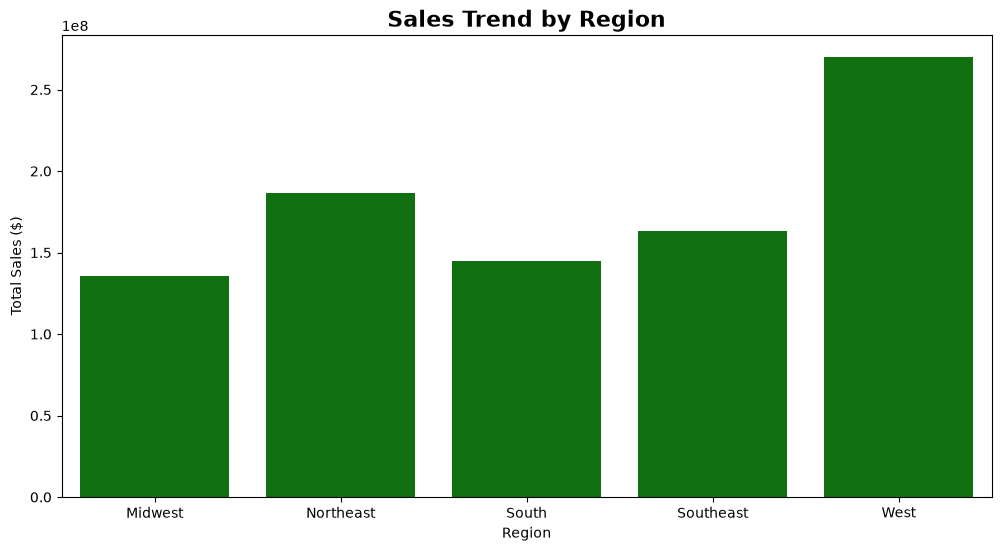

In [ ]:
regional_sales = df.groupby('Region')['Total Sales ($)'].sum().reset_index() #aggregate the data that we have. Add '.reset_index()' to rightly format region and total sales as column names 

plt.figure(figsize=(12, 6))   # wider and taller

sns.barplot(data =regional_sales, x='Region', y='Total Sales ($)', color = 'green') #line chart to showcase the regional distribution of total sales.

plt.title('Sales Trend by Region', fontsize=16, fontweight='bold')

What are the top-selling products? Create a bar chart to visualize the quantity of each product sold.

Text(0.5, 1.0, 'Average Products Sold')

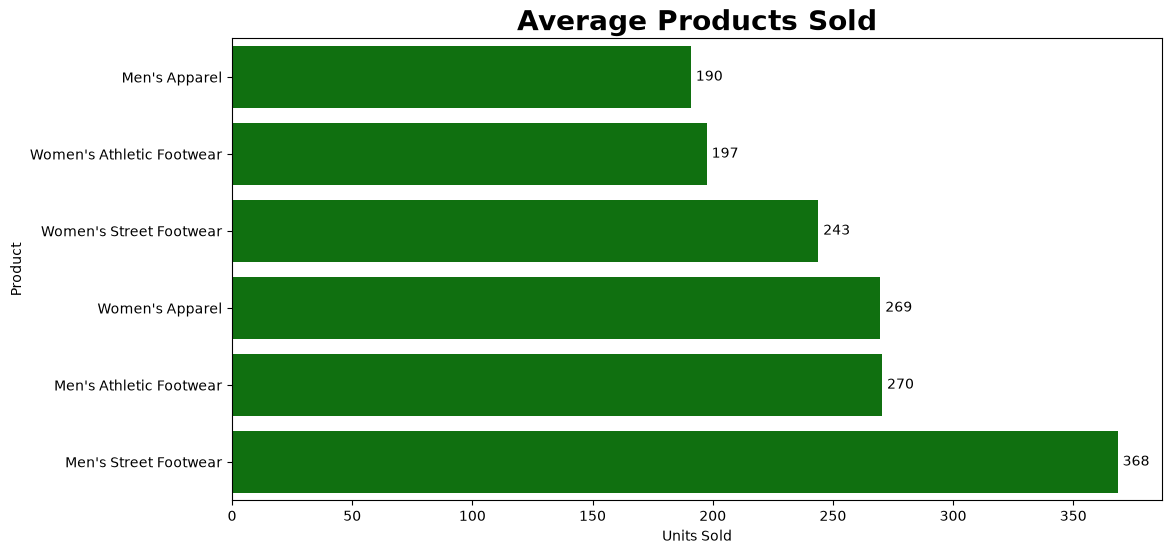

In [194]:
plt.figure(figsize=(12, 6))   # wider and taller

df_sorted = df.groupby('Product')['Units Sold'].mean().sort_values(ascending=True).reset_index() #sort in ascending order

ax = sns.barplot(data = df_sorted, x='Units Sold', y='Product', color='green') 

for bar in ax.patches: #add datalables
    ax.text(
        bar.get_width() + 2,            # x position (just past the bar end)
        bar.get_y() + bar.get_height() / 2,  # y position (middle of bar)
        f'{int(bar.get_width())}',       # the label text
        va='center', fontsize=10
    )

plt.title('Average Products Sold', fontsize = 20, fontweight='bold')

Price Per Unit vs. Operating Profit: Is there a relationship between the price per unit and the operating profit? Use a scatter plot to explore this relationship.

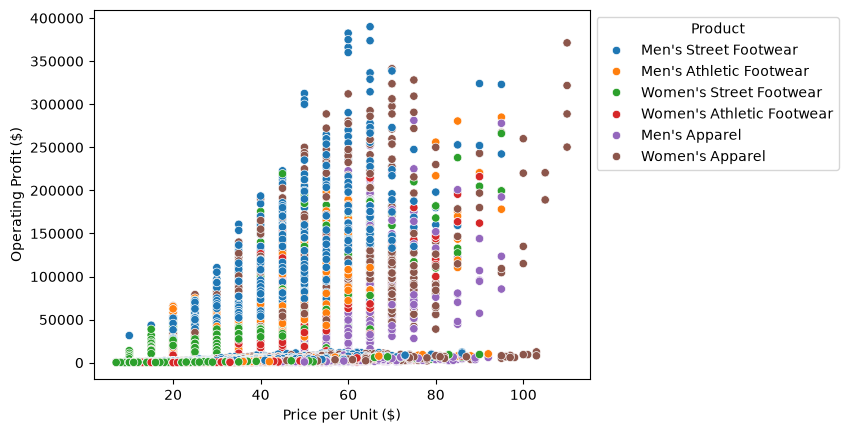

In [195]:
df

scatter_plot = sns.scatterplot(data=df, x='Price per Unit ($)', y='Operating Profit ($)', hue='Product')

sns.move_legend(scatter_plot, "upper left", bbox_to_anchor=(1, 1)) #move the legend outside of the visual


How does the sales method impact the operating margin? Create a box plot to compare the distribution of operating margins for different sales methods.

<Axes: xlabel='Operating Margin (%)', ylabel='Sales Method'>

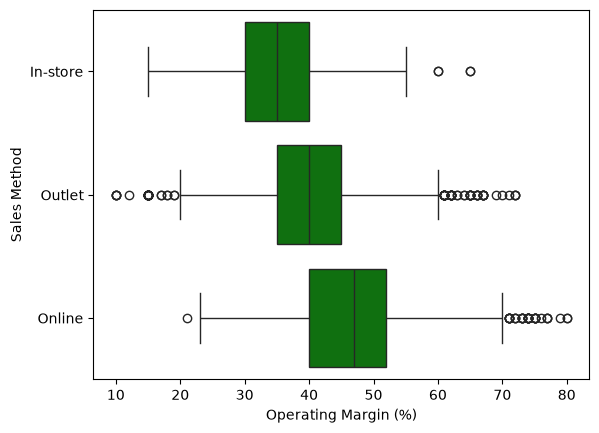

In [188]:
df

sns.boxplot(data=df, x='Operating Margin (%)', y='Sales Method', color='green')
